# 13_preprocess_dc_check_CHS

- 목적: 전처리의 DC 오프셋 제거(세그먼트 평균 제거)가 타당한지 점검하고, 대안(기저선 상수 `baseline`, 선형 추세 `detrend`, 누적 평균 `expanding`)을 같은 평가 계약으로 비교한다. 정상 전류의 DC는 거의 상수이고, 이상 세그먼트의 DC는 드리프트를 포함하며, 짧은 세그먼트의 "세그먼트 평균"은 DC가 아니라 사인 위상값이라는 가설을 수치로 확인한다.
- 입력: `data/raw`(없으면 zip 자동 추출), `data/processed/11_window_features.parquet`의 윈도우 키·`fold`·`block`·`state`
- 출력: `figures/13_preprocess_dc_check_CHS/`, `results/13_preprocess_dc_check_CHS/`(`seg_dc.csv` 등 12개 표. 모델 비교표(31)가 `metrics.csv`를 전부 모으므로 이 노트북은 `metrics.csv`를 만들지 않는다), `models/13_preprocess_dc_check_CHS/`(가중치, git 제외)
- 담당: CHS
- 심사 대응: 1번(DC·위상·드리프트 진단, 전처리 근거), 2번(전처리 변형 ablation: 규칙 1 + 모델 3종), 4번(DC 보조 지표의 경보 활용 가능성), 6번(전 과정 재현)

## 구성

| 절 | 내용 |
|---|---|
| A | DC 오프셋 진단: 세그먼트 내 상수성, 길이 대비 세그먼트 평균(이론 위상 손실 포함), 이상 DC의 위상 산물 여부, 하이패스 기각, 기타 품질 |
| B | 전처리 변형 4종(`mean`·`baseline`·`detrend`·`expanding`) x 모델 4종(`rule1_rms_ai0`·`pca_raw_ae_all3`·`mcd`·`cnn_deepant`), 1초 윈도우, group_kfold_seg 5 + time_block 4 |
| C | `baseline` 변형의 전류 잔여 DC를 단독 보조 지표로 쓸 수 있는지(판정 보드 #5) |
| D | 결론 |

운전 상태 번호: 0 = 고부하, 1 = 저부하. 파일명 규칙: 0x 진단 · 1x 전처리·피처 · 2x 모델 · 3x 분석

In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "13_preprocess_dc_check_CHS"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"font.family": "Malgun Gothic", "axes.unicode_minus": False, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e5e4e0", "axes.axisbelow": True,
                     "font.size": 9})
import data_quality as dq, preprocess as pp, features, evaluate as ev, split, benchmark_jiw as B, models_chs as MC
from scipy import signal, stats
FS = 10.0
t_nb = time.time()
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

13_preprocess_dc_check_CHS figures\13_preprocess_dc_check_CHS results\13_preprocess_dc_check_CHS


## 0. 입력: 형식 통일까지만 적용한 원본(DC 제거 전)

`unify_format`(진동 6자리, 전류 1.19209 격자 + 1자리)까지만 적용하고 DC는 그대로 둔다. 이후 A절은 이 표로 세그먼트 평균(DC)의 거동을 본다.

In [2]:
raw = pd.concat([dq.load("normal").assign(label=0), dq.load("outlier").assign(label=1)], ignore_index=True)
raw = pp.unify_format(pp.add_seg_uid(raw))          # 형식 통일까지만(DC 제거 전)
if "ts" not in raw.columns:
    raw["ts"] = pd.to_datetime(raw["TimeStamp"])
W = pd.read_parquet(paths.DATA_PROCESSED / "11_window_features.parquet")
W1 = W[W.win_s == 1.0].reset_index(drop=True)
CH = pp.SENSORS
seg_n = raw.groupby("seg_uid", sort=False).size()
seg_lab = raw.groupby("seg_uid", sort=False)["label"].first()
print("샘플", len(raw), "| 세그먼트 정상", int((seg_lab == 0).sum()), "이상", int((seg_lab == 1).sum()))
print("1초 윈도우", len(W1), "| 윈도우 있는 세그먼트", W1.seg_uid.nunique())

샘플 20600 | 세그먼트 정상 599 이상 21
1초 윈도우 3360 | 윈도우 있는 세그먼트 547


## A. DC 오프셋 진단 (심사 1번)

세그먼트·채널별로 (1) 세그먼트 평균(`_dc`)과 AC 표준편차, (2) 선형 추세가 설명하는 분산 비율 `lin_r2`(n≥4), (3) 후반 평균 − 전반 평균을 AC 표준편차로 나눈 `halfdiff_over_std`(n≥4), (4) 평균 제거 후 0 < f ≤ 0.2 Hz 전력 비율 `lf_frac`(n≥20)을 계산해 `seg_dc.csv`로 저장한다. DC가 진짜 상수라면 `lin_r2`·`halfdiff`·`lf_frac`이 작아야 한다.

In [3]:
rows = []
for u, g in raw.groupby("seg_uid", sort=False):
    n = len(g)
    row = {"seg_uid": u, "label": int(g["label"].iloc[0]), "n": n}
    t = np.arange(n, dtype=float)
    for ch in CH:
        x = g[ch].to_numpy(float)
        mu, sd = x.mean(), x.std()
        row[f"{ch}_dc"] = mu
        row[f"{ch}_ac_std"] = sd
        if n >= 4:
            row[f"{ch}_lin_r2"] = float(np.corrcoef(t, x)[0, 1] ** 2) if sd > 0 else np.nan
            h = n // 2
            row[f"{ch}_halfdiff_over_std"] = float((x[-h:].mean() - x[:h].mean()) / sd) if sd > 0 else np.nan
        if n >= 20:
            f, P = signal.periodogram(x - mu, fs=FS, window="boxcar", detrend=False)
            tot = P[f > 0].sum()
            row[f"{ch}_lf_frac"] = float(P[(f > 0) & (f <= 0.2)].sum() / tot) if tot > 0 else np.nan
    rows.append(row)
seg_dc = pd.DataFrame(rows)
seg_dc.to_csv(RES / "seg_dc.csv", index=False)
print(seg_dc.shape)
seg_dc.groupby("label")[["n", "AI2_Current_dc", "AI2_Current_ac_std"]].describe().T.round(3)

(620, 18)


label                           0        1
n                  count  599.000   21.000
                   mean    33.389   28.571
                   std     16.382   17.537
                   min      1.000    3.000
                   25%     20.000   15.000
                   50%     37.000   28.000
                   75%     50.000   47.000
                   max     50.000   50.000
AI2_Current_dc     count  599.000   21.000
                   mean     1.929   35.522
                   std     36.462  134.447
                   min   -235.600 -184.750
                   25%     -2.896  -74.388
                   50%      0.576    1.902
                   75%      6.327  155.362
                   max    222.533  272.428
AI2_Current_ac_std count  599.000   21.000
                   mean   108.787   79.996
                   std     41.808   32.068
                   min      0.000   18.775
                   25%     82.058   56.816
                   50%     92.119   74.327
                   75%    144.936  101.610
                   max    193.480  132.907

### A-1 세그먼트 내 DC 상수성 (n ≥ 20)

label x 채널별 `lin_r2`·`halfdiff_over_std`·`lf_frac`의 q05/q50/q95. 검증용 기대값: 정상 전류 lin_r2 q50 ≈ 0.02, 이상 전류 lin_r2 q50 ≈ 0.14 · q95 ≈ 0.70, lf_frac q95 ≈ 0.53.

In [4]:
d20 = seg_dc[seg_dc.n >= 20]
recs = []
for lab, nm in [(0, "정상"), (1, "이상")]:
    for ch in CH:
        for m in ["lin_r2", "halfdiff_over_std", "lf_frac"]:
            v = d20.loc[d20.label == lab, f"{ch}_{m}"].dropna()
            q = v.quantile([0.05, 0.5, 0.95]).to_numpy() if len(v) else [np.nan] * 3
            recs.append({"label": nm, "channel": ch, "metric": m, "n_seg": len(v), "q05": q[0], "q50": q[1], "q95": q[2]})
dc_constancy = pd.DataFrame(recs)
dc_constancy.to_csv(RES / "dc_constancy.csv", index=False)
dc_constancy.round(3)

,label,channel,metric,n_seg,q05,q50,q95
0,정상,AI0_Vibration,lin_r2,452,0.000,0.010,0.223
1,정상,AI0_Vibration,halfdiff_over_std,452,-0.705,0.013,0.720
2,정상,AI0_Vibration,lf_frac,452,0.000,0.000,0.233
3,정상,AI1_Vibration,lin_r2,452,0.000,0.004,0.085
4,정상,AI1_Vibration,halfdiff_over_std,452,-0.423,0.010,0.382
5,정상,AI1_Vibration,lf_frac,452,0.000,0.000,0.056
6,정상,AI2_Current,lin_r2,452,0.000,0.023,0.113
7,정상,AI2_Current,halfdiff_over_std,452,-0.589,-0.001,0.602
8,정상,AI2_Current,lf_frac,452,0.000,0.000,0.000
9,이상,AI0_Vibration,lin_r2,13,0.012,0.029,0.149


**결과**: 정상 전류(n ≥ 20, 452개)의 선형 추세 설명력 `lin_r2`는 q50 0.023 · q95 0.113, 저주파(≤ 0.2 Hz) 전력 비율 `lf_frac` q95 0.000, 후반-전반 평균 차이/AC std는 q05~q95 −0.59 ~ 0.60(중앙값 −0.001)이다. 이상 전류(13개)는 `lin_r2` q50 0.136 · q95 0.696, `lf_frac` q95 0.528, `halfdiff` 중앙값 0.339로 모두 정상보다 크다. 진동은 정상에서 추세가 약하고(`lin_r2` q50 0.004~0.010, 정상 AI0 q95 0.223), 이상 AI1은 q50 0.107 · q95 0.407로 전류만큼은 아니어도 드리프트가 있다.

**시사점**: 정상 전류의 DC는 세그먼트 안에서 상수로 봐도 되지만(추세 설명력 2%), 이상 세그먼트는 느린 드리프트가 분산의 최대 70%(q95 기준 0.696), 저주파 전력의 53%(q95)를 차지한다. 즉 "평균 한 값을 빼면 끝"이라는 가정은 정상에서만 성립한다.

### A-2 세그먼트 평균 vs 길이

정상 전류의 세그먼트 평균(DC)을 길이 구간별로 보고 Spearman(|DC|, n)을 계산한다. 같은 표에 **이론 손실**을 붙인다: 0.6 Hz 사인(10 Hz 샘플링, 한 주기 16.7샘플)을 길이 n 세그먼트에서 평균 제거했을 때 남는 RMS ÷ 참 RMS를 36개 위상에 대해 평균·최소로 계산했다. 기대: n=5 ≈ 0.47, n=10 ≈ 0.84, n=17 ≈ 1.00.

In [5]:
cur = seg_dc[seg_dc.label == 0].copy()
cur["absdc"] = cur["AI2_Current_dc"].abs()
rho, p = stats.spearmanr(cur["absdc"], cur["n"])
print(f"정상 전류 Spearman(|DC|, n) = {rho:.3f} (p={p:.1e}, n_seg={len(cur)})")
bins = [0, 8, 16, 25, 34, 49, 50]
labs = ["(0,8]", "(8,16]", "(16,25]", "(25,34]", "(34,49]", "[50]"]
cur["bin"] = pd.cut(cur["n"], bins=bins, labels=labs)
meas = cur.groupby("bin", observed=True).agg(n_seg=("n", "size"), dc_median=("AI2_Current_dc", "median"),
                                             absdc_q95=("absdc", lambda s: s.quantile(0.95)), absdc_max=("absdc", "max")).reset_index()
meas.insert(0, "section", "실측 길이구간(정상 전류)")
meas = meas.rename(columns={"bin": "length_bin"})
phases = np.arange(36) * 2 * np.pi / 36
theory = []
for n in [3, 5, 8, 10, 17, 25, 50]:
    t = np.arange(n) / FS
    r = np.array([np.sin(2 * np.pi * 0.6 * t + ph).std() / (1 / np.sqrt(2)) for ph in phases])
    theory.append({"section": "이론: 평균 제거 후 RMS/참 RMS", "length_bin": f"n={n}", "theory_rms_ratio_mean": r.mean(), "theory_rms_ratio_min": r.min()})
dc_vs_length = pd.concat([meas, pd.DataFrame(theory)], ignore_index=True)
dc_vs_length.to_csv(RES / "dc_vs_length.csv", index=False)
dc_vs_length.round(3)

정상 전류 Spearman(|DC|, n) = -0.835 (p=7.7e-157, n_seg=599)


,section,length_bin,n_seg,dc_median,absdc_q95,absdc_max,theory_rms_ratio_mean,theory_rms_ratio_min
0,실측 길이구간(정상 전류),"(0,8]",61.0,11.350,182.383,235.600,NaN,NaN
1,실측 길이구간(정상 전류),"(8,16]",69.0,-2.681,90.256,143.044,NaN,NaN
2,실측 길이구간(정상 전류),"(16,25]",77.0,1.626,45.275,52.942,NaN,NaN
3,실측 길이구간(정상 전류),"(25,34]",66.0,1.295,28.165,34.444,NaN,NaN
4,실측 길이구간(정상 전류),"(34,49]",124.0,1.119,22.508,31.959,NaN,NaN
5,실측 길이구간(정상 전류),[50],202.0,0.572,1.185,1.452,NaN,NaN
6,이론: 평균 제거 후 RMS/참 RMS,n=3,NaN,NaN,NaN,NaN,0.276,0.048
7,이론: 평균 제거 후 RMS/참 RMS,n=5,NaN,NaN,NaN,NaN,0.470,0.164
8,이론: 평균 제거 후 RMS/참 RMS,n=8,NaN,NaN,NaN,NaN,0.718,0.401
9,이론: 평균 제거 후 RMS/참 RMS,n=10,NaN,NaN,NaN,NaN,0.843,0.572


saved

 figures\13_preprocess_dc_check_CHS\dc_vs_length.png


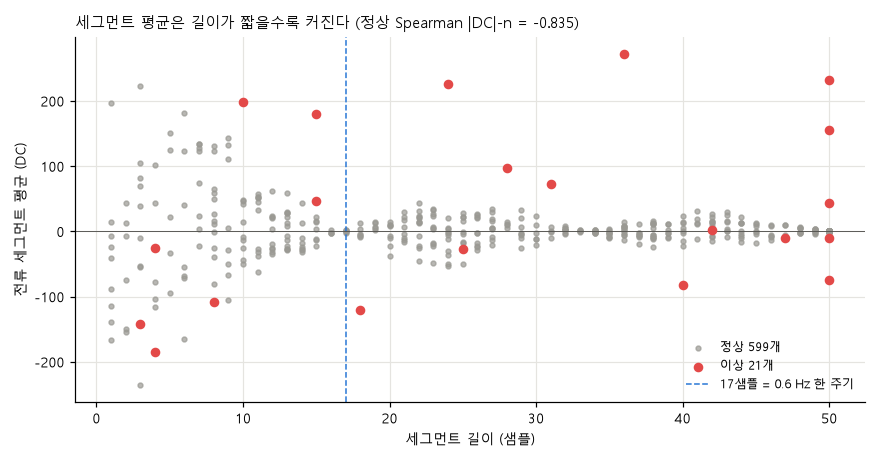

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
nm = seg_dc[seg_dc.label == 0]; ol = seg_dc[seg_dc.label == 1]
ax.scatter(nm["n"], nm["AI2_Current_dc"], s=10, c="#9a9993", label=f"정상 {len(nm)}개", alpha=0.7)
ax.scatter(ol["n"], ol["AI2_Current_dc"], s=28, c="#e34948", label=f"이상 {len(ol)}개", zorder=3)
ax.axvline(17, color="#2a78d6", ls="--", lw=1, label="17샘플 = 0.6 Hz 한 주기")
ax.axhline(0, color="#52514e", lw=0.6)
ax.set_xlabel("세그먼트 길이 (샘플)"); ax.set_ylabel("전류 세그먼트 평균 (DC)")
ax.set_title(f"세그먼트 평균은 길이가 짧을수록 커진다 (정상 Spearman |DC|-n = {rho:.3f})", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8)
paths.save_fig(FIG, "dc_vs_length.png")
display(Image(FIG / "dc_vs_length.png"))

**결과**: 정상 전류 |세그먼트 평균|과 길이의 Spearman은 −0.835(599개)다. 길이 [50]의 |DC| q95는 1.19(최대 1.45, 중앙값 0.57)로 사실상 상수인데, 길이가 짧아질수록 (34,49] 22.5 → (25,34] 28.2 → (16,25] 45.3 → (8,16] 90.3 → (0,8] 182.4(최대 235.6)로 커진다. 0.6 Hz 사인의 이론 손실(평균 제거 후 RMS ÷ 참 RMS, 36위상 평균/최소)은 n=3 0.276/0.048, n=5 0.470/0.164, n=8 0.718/0.401, n=10 0.843/0.572, n=17 1.000/0.990, n=25 0.977/0.953, n=50 1.000이다.

**시사점**: 정상 세그먼트의 21.7%(130/599)가 17샘플(0.6 Hz 한 주기) 미만이다. 이 구간의 "세그먼트 평균"은 DC가 아니라 사인의 위상값이고, 평균 제거는 AC를 깎는다(n=5에서 평균 47%만 남음). 길이 17 이상에서 손실이 사라지고 |DC|가 정상 상수(0.57)로 수렴하므로 **긴 세그먼트에서 추정한 상수 기저선(`baseline`)이 짧은 세그먼트에도 일관되게 적용되는 후보**가 된다.

### A-3 이상 DC는 위상 산물이 아니다

길이 n ≥ 24(사인 1.4주기 이상)인 세그먼트만 비교한다. 이 길이에서는 위상 때문에 생기는 평균 편차가 작으므로, 이상 세그먼트의 큰 DC가 위상 효과로 설명되지 않음을 보인다.

In [7]:
l24 = seg_dc[seg_dc.n >= 24].copy()
nn = l24[l24.label == 0]["AI2_Current_dc"].abs()
oo = l24[l24.label == 1].sort_values("AI2_Current_dc", key=lambda s: s.abs(), ascending=False)
tab = [{"group": "정상 요약", "seg_uid": f"n_seg={len(nn)}", "n": np.nan, "current_dc": np.nan,
        "abs_dc_q95": nn.quantile(0.95), "abs_dc_q99": nn.quantile(0.99), "abs_dc_max": nn.max()}]
for _, r in oo.iterrows():
    tab.append({"group": "이상", "seg_uid": r["seg_uid"], "n": r["n"], "current_dc": r["AI2_Current_dc"],
                "abs_dc_q95": np.nan, "abs_dc_q99": np.nan, "abs_dc_max": abs(r["AI2_Current_dc"])})
dc_out = pd.DataFrame(tab)
dc_out.to_csv(RES / "dc_outlier_vs_normal_len24.csv", index=False)
print(f"정상(n>=24) |전류 DC| 최대 {nn.max():.2f}, q99 {nn.quantile(0.99):.2f} | 이상 n>=24 세그먼트 {len(oo)}개, |DC| 최소 {oo['AI2_Current_dc'].abs().min():.1f}")
dc_out.round(2)

정상(n>=24) |전류 DC| 최대 52.94, q99 34.23 | 이상 n>=24 세그먼트 13개, |DC| 최소 1.9


,group,seg_uid,n,current_dc,abs_dc_q95,abs_dc_q99,abs_dc_max
0,정상 요약,n_seg=413,NaN,NaN,23.3,34.23,52.94
1,이상,outlier_17,36.0,272.43,NaN,NaN,272.43
2,이상,outlier_16,50.0,231.88,NaN,NaN,231.88
3,이상,outlier_18,24.0,225.55,NaN,NaN,225.55
4,이상,outlier_15,50.0,155.36,NaN,NaN,155.36
5,이상,outlier_13,28.0,97.25,NaN,NaN,97.25
6,이상,outlier_7,40.0,-81.42,NaN,NaN,81.42
7,이상,outlier_6,50.0,-74.39,NaN,NaN,74.39
8,이상,outlier_3,31.0,73.45,NaN,NaN,73.45
9,이상,outlier_1,50.0,43.99,NaN,NaN,43.99


**결과**: n ≥ 24인 정상 세그먼트 413개의 |전류 DC|는 q99 34.23, 최대 52.94다. 같은 길이 조건의 이상 세그먼트 13개 중 8개(17: 272.4, 16: 231.9, 18: 225.6, 15: 155.4, 13: 97.3, 7: −81.4, 6: −74.4, 3: 73.5)가 정상 최대 52.94를 넘는다. 나머지 5개(1: 44.0, 8: −26.2, 11: −9.8, 2: −9.3, 12: 1.9)는 정상 범위다. 19·20은 길이 24 미만이라 이 비교에서 빠진다.

**시사점**: 길이 24 이상에서는 위상으로 설명되는 평균 편차가 정상에서 최대 53 이하이므로, 이상 세그먼트 17·16·18·15의 155~272는 위상 산물이 아니라 실제 오프셋이다. 다만 길이 24 이상 이상 세그먼트의 5/13은 DC 이상이 없어 DC는 이상의 일부 징후일 뿐이다.

### A-4 하이패스/밴드패스 기각

길이 50 정상 세그먼트 200개의 전류에 2차 Butterworth 하이패스(fc 0.1·0.2·0.5·1.0 Hz)를 zero-phase(`filtfilt`)와 causal(`lfilter`)로 적용하고 평균 제거 결과와의 상대 RMS 오차 중앙값을 낸다. 또 +200 DC 스텝을 더한 신호에 필터를 적용해 참 AC 대비 절대오차 평균을 구간(0~1초, 1~2초, 4~5초)별로 잰다. 사전 점검 기대값: fc=0.2 zero-phase 0.42, causal 0.49, 첫 1초 절대오차 ≈ 100(길이 50 정상 세그먼트의 AC std 중앙값 약 104와 같은 자릿수).

In [8]:
g50 = [u for u, n in seg_n.items() if n == 50 and seg_lab[u] == 0][:200]
Xc = np.stack([raw.loc[raw.seg_uid == u, "AI2_Current"].to_numpy(float) for u in g50])
AC = Xc - Xc.mean(1, keepdims=True)
print("길이 50 정상 세그먼트", len(g50), "| AC std 중앙값", round(float(np.median(AC.std(1))), 1))
rms = lambda a: np.sqrt((a ** 2).mean(-1))
STEP = 200.0
hp = []
for fc in [0.1, 0.2, 0.5, 1.0]:
    b, a = signal.butter(2, fc, "high", fs=FS)
    for mode in ["zero_phase", "causal"]:
        f = (lambda x: signal.filtfilt(b, a, x, axis=-1)) if mode == "zero_phase" else (lambda x: signal.lfilter(b, a, x, axis=-1))
        y = f(Xc)
        rel = rms(y - AC) / rms(AC)
        ys = f(AC + STEP)
        err = np.abs(ys - AC)
        hp.append({"fc_hz": fc, "mode": mode, "rel_rms_err_median": float(np.median(rel)),
                   "step_abs_err_0_1s": float(err[:, :10].mean()), "step_abs_err_1_2s": float(err[:, 10:20].mean()),
                   "step_abs_err_4_5s": float(err[:, 40:50].mean())})
highpass = pd.DataFrame(hp)
highpass.to_csv(RES / "highpass_rejection.csv", index=False)
highpass.round(3)

길이 50 정상 세그먼트 200 | AC std 중앙값 104.2


,fc_hz,mode,rel_rms_err_median,step_abs_err_0_1s,step_abs_err_1_2s,step_abs_err_4_5s
0,0.1,zero_phase,0.546,82.998,31.106,88.670
1,0.1,causal,0.253,123.321,31.077,37.803
2,0.2,zero_phase,0.420,68.333,9.700,52.847
3,0.2,causal,0.489,97.983,58.105,51.235
4,0.5,zero_phase,0.405,52.066,35.837,50.247
5,0.5,causal,1.084,111.657,121.720,120.857
6,1.0,zero_phase,0.891,95.878,96.735,95.689
7,1.0,causal,1.202,124.297,132.438,130.998


saved figures\13_preprocess_dc_check_CHS\highpass_example.png


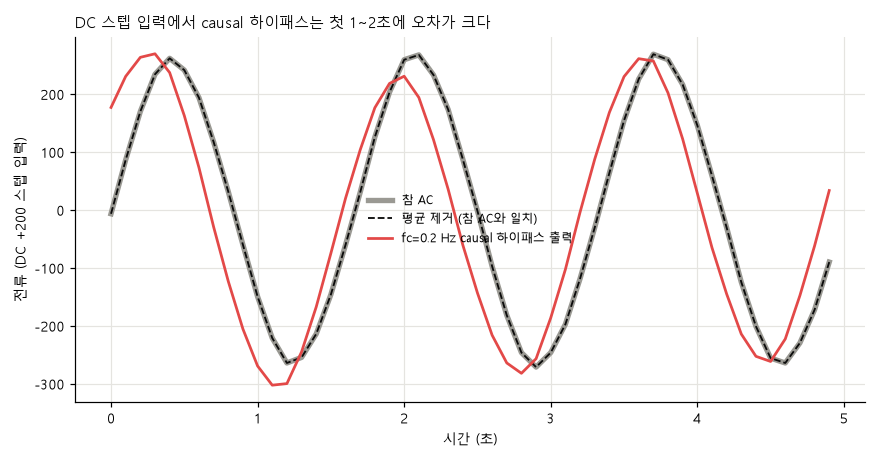

In [9]:
i = int(np.argmax(AC.std(1)))
b, a = signal.butter(2, 0.2, "high", fs=FS)
sig = AC[i] + STEP
yc = signal.lfilter(b, a, sig)
tt = np.arange(50) / FS
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(tt, AC[i], color="#9a9993", lw=3.5, label="참 AC")
ax.plot(tt, sig - sig.mean(), color="#0b0b0b", lw=1.2, ls="--", label="평균 제거 (참 AC와 일치)")
ax.plot(tt, yc, color="#e34948", lw=1.8, label="fc=0.2 Hz causal 하이패스 출력")
ax.set_xlabel("시간 (초)"); ax.set_ylabel("전류 (DC +200 스텝 입력)")
ax.set_title("DC 스텝 입력에서 causal 하이패스는 첫 1~2초에 오차가 크다", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8)
paths.save_fig(FIG, "highpass_example.png")
display(Image(FIG / "highpass_example.png"))

**결과**: 길이 50 정상 200개(AC std 중앙값 104.2)에서 평균 제거 대비 상대 RMS 오차 중앙값은 fc=0.1 zero-phase 0.546 / causal 0.253, fc=0.2 0.420 / 0.489, fc=0.5 0.405 / 1.084, fc=1.0 0.891 / 1.202다. +200 DC 스텝 입력에서 causal fc=0.2의 참 AC 대비 절대오차 평균은 0~1초 98.0, 1~2초 58.1, 4~5초 51.2이고, fc=0.1은 123.3 / 31.1 / 37.8, fc=0.5는 111.7 / 121.7 / 120.9다(0.5 Hz 이상은 0.6 Hz AC 자체를 왜곡). zero-phase fc=0.2도 68.3 / 9.7 / 52.8이다.

**시사점**: AC를 보존(상대 오차 0.25 미만)하면서 5초 안에 DC 스텝을 지우는 차단 주파수가 없다. 가장 낮은 오차의 fc=0.1 causal도 첫 1초 오차가 123(AC std 104 초과)이고 4~5초에도 37.8이 남는다. 따라서 하이패스·밴드패스는 기각하고 상수 제거(`mean`/`baseline`)를 유지한다.

### A-5 그 밖의 품질 점검

label별 세그먼트 내 샘플 간격(Δt) 분위수, 중복 타임스탬프, 채널별 범위, 5σ 초과 비율(세그먼트 평균 제거 후, label 내 표준편차 기준), 세그먼트 길이 분포를 한 표로 모은다.

In [10]:
rows = []
raw["dt_in"] = raw.groupby("seg_uid")["ts"].diff().dt.total_seconds()
for lab, nm in [(0, "정상"), (1, "이상")]:
    d = raw[raw.label == lab]
    q = d["dt_in"].dropna().quantile([0.01, 0.5, 0.99])
    for k, v in zip(["q01", "q50", "q99"], q):
        rows.append({"label": nm, "channel": "", "item": f"세그먼트 내 dt {k} (초)", "value": float(v)})
    rows.append({"label": nm, "channel": "", "item": "중복 타임스탬프 수", "value": int(d["ts"].duplicated().sum())})
    for ch in CH:
        x = d[ch]
        ac = x - d.groupby("seg_uid")[ch].transform("mean")
        rows.append({"label": nm, "channel": ch, "item": "min", "value": float(x.min())})
        rows.append({"label": nm, "channel": ch, "item": "max", "value": float(x.max())})
        rows.append({"label": nm, "channel": ch, "item": "|x-세그먼트평균|>5σ 비율", "value": float((ac.abs() > 5 * ac.std()).mean())})
    ns = seg_n[seg_lab == lab]
    rows += [{"label": nm, "channel": "", "item": "세그먼트 수", "value": int(len(ns))},
             {"label": nm, "channel": "", "item": "길이 n=50 개수", "value": int((ns == 50).sum())},
             {"label": nm, "channel": "", "item": "길이 n<10 개수", "value": int((ns < 10).sum())},
             {"label": nm, "channel": "", "item": "길이 n<17 개수", "value": int((ns < 17).sum())},
             {"label": nm, "channel": "", "item": "길이 중앙값", "value": float(ns.median())}]
misc = pd.DataFrame(rows)
misc.to_csv(RES / "misc_quality.csv", index=False)
raw = raw.drop(columns="dt_in")
misc.pivot_table(index=["item", "channel"], columns="label", values="value", sort=False).round(4)

label                                  정상        이상
item              channel                          
세그먼트 내 dt q01 (초)                  0.1000    0.1000
세그먼트 내 dt q50 (초)                  0.1000    0.1000
세그먼트 내 dt q99 (초)                  0.1000    0.1000
중복 타임스탬프 수                         1.0000    0.0000
min               AI0_Vibration   -0.3146   -1.5027
                  AI1_Vibration   -0.3665   -0.7513
                  AI2_Current   -271.8000 -399.4000
max               AI0_Vibration    0.3517    1.8032
                  AI1_Vibration    0.3998    0.5093
                  AI2_Current    273.0000  538.8000
|x-세그먼트평균|>5σ 비율  AI0_Vibration    0.0000    0.0000
                  AI1_Vibration    0.0000    0.0000
                  AI2_Current      0.0000    0.0000
세그먼트 수                           599.0000   21.0000
길이 n=50 개수                       202.0000    5.0000
길이 n<10 개수                        69.0000    4.0000
길이 n<17 개수                       130.0000    7.0000
길이 중앙값                            37.0000   28.0000

**결과**: 세그먼트 안 샘플 간격은 정상·이상 모두 q01/q50/q99 = 0.1초(결측 구간 없음), 중복 타임스탬프는 정상 1개 · 이상 0개, 세그먼트 평균 제거 후 5σ 초과 샘플은 모든 채널에서 0이다. 전류 범위는 정상 −271.8 ~ 273.0, 이상 −399.4 ~ 538.8이고 이상 AI0는 −1.50 ~ 1.80(정상 ±0.35)이다. 길이 분포는 정상 n=50 202개 · n<10 69개 · n<17 130개(중앙값 37), 이상 n=50 5개 · n<10 4개 · n<17 7개(중앙값 28)다.

**시사점**: 시간축·이상치 문제는 없고, DC 처리의 핵심 위험은 짧은 세그먼트 비중이다(정상 21.7%, 이상 33.3%가 n<17).

## B. 전처리 변형 ablation (심사 2·4번)

| variant | 의미 |
|---|---|
| `mean` | 세그먼트 평균 제거 — 24~27과 같은 benchmark_v1 |
| `baseline` | 정상 전체의 긴 세그먼트(n ≥ 17)에서 `fit_baseline`으로 추정한 채널별 상수를 뺀다. 길이 무관·causal 후보 |
| `detrend` | 세그먼트별 1차 선형 추세를 뺀다(드리프트까지 제거하는 오프라인 ablation) |
| `expanding` | 세그먼트 안 누적 평균을 뺀다(causal ablation) |

모델 4종: `rule1_rms_ai0`(AI0 1초 RMS, 임계 = train 정상 q99, 이 노트북에서 직접 구현), `pca_raw_ae_all3`(27의 선형 복원 대조군), `mcd`[amp 18열], `cnn_deepant`(30 epoch, seed 0). 평가 계약은 24~27과 같다(1초 윈도우, group_kfold_seg 5 + time_block 4, 임계 = train 정상 q99).

**주의**: `baseline` 기저선은 분할마다 다시 적합하지 않고 정상 전체로 1회 적합한다(아래 B-0에서 fold별 추정치 변동을 따로 확인). `B.run`의 합성 이상 주입은 주입 후 세그먼트 평균을 다시 빼는 규약이라 `inj_*` 열은 변형 간 비교용으로 쓰지 않는다.

In [11]:
raw_all = pd.concat(dq.load_all().values(), ignore_index=True)       # 라벨 열 없음, B.load_inputs와 같은 입력
uni = pp.unify_format(pp.add_seg_uid(raw_all))                         # 기저선 추정용 (DC 제거 전)
normal_all = uni[uni["src"] == "normal"]
b_all = pp.fit_baseline(normal_all, min_len=17)
print("정상 전체 기저선:", {k: round(v, 4) for k, v in b_all.items()})
VARIANTS = ["mean", "baseline", "detrend", "expanding"]
pre_by = {"mean": pp.preprocess(raw_all),
          "baseline": pp.preprocess(raw_all, dc_method="baseline", baseline=b_all),
          "detrend": pp.preprocess(raw_all, dc_method="detrend"),
          "expanding": pp.preprocess(raw_all, dc_method="expanding")}
segs_by, W1_by = {}, {}
for v in VARIANTS:
    segs_by[v] = {u: g[pp.SENSORS].to_numpy(np.float32) for u, g in pre_by[v].groupby("seg_uid", sort=False)}
    Wv = W1.copy()
    Wv[B.AMP_COLS] = B.recompute_features(segs_by[v], W1, B.AMP_COLS).to_numpy()
    W1_by[v] = Wv
diff = np.abs(W1_by["mean"][B.AMP_COLS].to_numpy() - W1[B.AMP_COLS].to_numpy()).max()
_a, _b = W1_by["mean"][B.AMP_COLS].to_numpy(), W1[B.AMP_COLS].to_numpy()
rel = (np.abs(_a - _b) / np.maximum(np.abs(_b), 1e-3)).max()
print(f"mean 변형 재계산 vs parquet 진폭 18열 최대 절대 차이: {diff:.3e} (<= 1e-6: {diff <= 1e-6}) | 최대 상대 차이(분모 max(|값|, 1e-3)): {rel:.3e}")
print("절대 차이가 큰 열:", B.AMP_COLS[int(np.abs(_a - _b).max(0).argmax())], "(float32 세그먼트 배열 vs parquet float64 — 전류 열은 값 크기 ~150)")

정상 전체 기저선: {'AI0_Vibration': -0.0, 'AI1_Vibration': 0.0, 'AI2_Current': 0.576}


mean 변형 재계산 vs parquet 진폭 18열 최대 절대 차이: 2.441e-05 (<= 1e-6: False) | 최대 상대 차이(분모 max(|값|, 1e-3)): 4.668e-05
절대 차이가 큰 열: AI2_Current_p2p (float32 세그먼트 배열 vs parquet float64 — 전류 열은 값 크기 ~150)


### B-0 기저선의 fold별 변동

gkf fold 0~4의 train 정상 세그먼트, time_block k=1~4의 train 정상 세그먼트로 각각 `fit_baseline`을 다시 적합해 채널별 값을 비교한다. 전류 기저선이 0.4~0.8 범위이고 양자화 격자(1.19)보다 작아야 "1회 적합" 단순화가 결과를 바꾸지 않는다고 볼 수 있다.

In [12]:
seg_info = W1.groupby("seg_uid").agg(fold=("fold", "first"), block=("block", "first"), label=("label", "first"))
nrm = seg_info[seg_info.label == 0]
rows = []
def fit_on(uids):
    return pp.fit_baseline(normal_all[normal_all["seg_uid"].isin(uids)], min_len=17)
for k in range(5):
    uids = nrm.index[nrm.fold != k]
    rows.append({"split": "group_kfold_seg", "fold": k, "n_train_seg": len(uids), **fit_on(uids)})
for k in range(1, 5):
    uids = nrm.index[nrm.block < k]
    rows.append({"split": "time_block", "fold": k, "n_train_seg": len(uids), **fit_on(uids)})
rows.append({"split": "전체 정상(노트북 사용값)", "fold": -1, "n_train_seg": int(normal_all.seg_uid.nunique()), **b_all})
bfold = pd.DataFrame(rows)
bfold.to_csv(RES / "baseline_by_fold.csv", index=False)
cur_b = bfold["AI2_Current"]
print(f"전류 기저선 범위 {cur_b.min():.3f} ~ {cur_b.max():.3f} | 0.4~0.8 안: {bool(((cur_b >= 0.4) & (cur_b <= 0.8)).all())} | 격자 1.19209 미만: {bool((cur_b.abs() < pp.CUR_STEP).all())}")
bfold.round(4)

전류 기저선 범위 0.502 ~ 0.596 | 0.4~0.8 안: True | 격자 1.19209 미만: True


,split,fold,n_train_seg,AI0_Vibration,AI1_Vibration,AI2_Current
0,group_kfold_seg,0,421,-0.0,0.0,0.572
1,group_kfold_seg,1,426,-0.0,0.0,0.596
2,group_kfold_seg,2,428,-0.0,0.0,0.592
3,group_kfold_seg,3,420,-0.0,0.0,0.572
4,group_kfold_seg,4,425,0.0,0.0,0.574
5,time_block,1,113,-0.0,-0.0,0.502
6,time_block,2,215,-0.0,-0.0,0.552
7,time_block,3,314,-0.0,0.0,0.584
8,time_block,4,422,-0.0,0.0,0.572
9,전체 정상(노트북 사용값),-1,599,-0.0,0.0,0.576


**결과**: 전류 기저선은 gkf fold 0~4가 0.572 ~ 0.596, time_block k=1~4가 0.502 ~ 0.584(k=1은 train 정상 113개로 가장 낮은 0.502), 정상 전체 사용값은 0.576이다. 모두 0.4~0.8 범위이고 양자화 격자 1.19209 미만이다. 진동 두 채널 기저선은 0(소수 4자리 반올림 기준 ±0.0)이다.

**시사점**: fold마다 달라지는 폭이 전류 AC std(약 100)의 0.1% 이하(최대 0.094)이므로, 기저선을 분할마다 다시 적합하지 않고 정상 전체로 1회 적합해도 평가 결과가 달라지지 않는다고 볼 수 있다(단 time_block k=1처럼 train이 작은 분할은 0.07 낮다).

### B-1 형식 누수 점검: 전처리 후에도 세그먼트 DC가 남는가

`baseline`·`expanding`은 이상 파일 세그먼트의 DC 오프셋을 **제거하지 않는다**(02 §2 형식 누수의 DC 항목). 변형별로 DC 제거 후 세그먼트 평균의 절댓값 |평균|이 정상(0)과 이상(1)을 얼마나 가르는지 세그먼트 단위 AUC로 확인한다(전체 620개 세그먼트). `preprocess.format_features`를 변형별 전처리 결과에 그대로 적용한 형식 피처(소수 자릿수·고유값 비율·격자 정수배 비율 포함)의 AUC도 함께 둔다. AUC는 이상 쪽이 클 때 1에 가깝고, 방향 무관 값 `auc_sym = max(AUC, 1−AUC)`도 적는다.

**읽는 법**: `baseline`·`expanding`의 실제 이상 탐지 수치는 파형이 아니라 이상 파일의 DC 오프셋(계측 체인 변경과 구분 불가, 판정 보드 #5)의 도움을 받았을 수 있다. 파형 탐지의 정직한 비교는 `mean` vs `detrend`이고, `baseline`은 causal 배포 후보이므로 실제 이상 수치는 상한으로 읽으며 C절(DC 보조 지표)과 함께 해석한다.

In [13]:
rows = []
for v in VARIANTS:
    pv = pre_by[v]
    segm = pv.groupby("seg_uid", sort=False)[pp.SENSORS].mean()
    y = (segm.index.str.startswith("outlier")).astype(int)
    for ch in pp.SENSORS:
        a = ev.auc(y, segm[ch].abs().round(9).to_numpy())
        rows.append({"variant": v, "channel": ch, "feature": "abs_segment_mean", "auc": a, "auc_sym": max(a, 1 - a)})
    ff = pp.format_features(pv)
    yf = (ff.index.str.startswith("outlier")).astype(int)
    for c in ff.columns:
        a = ev.auc(yf, ff[c].to_numpy())
        ch = next(c_ for c_ in pp.SENSORS if c.startswith(c_))
        rows.append({"variant": v, "channel": ch, "feature": "format_features:" + c[len(ch) + 1:], "auc": a,
                     "auc_sym": max(a, 1 - a) if np.isfinite(a) else np.nan})
leak = pd.DataFrame(rows)
leak.to_csv(RES / "leak_check_by_variant.csv", index=False)
print("분리 열: abs_segment_mean (세그먼트 평균 절댓값), format_features:* (형식 피처)")
display(leak[leak.feature == "abs_segment_mean"].pivot(index="channel", columns="variant", values="auc")[VARIANTS].round(4))
display(leak[leak.feature != "abs_segment_mean"].pivot_table(index=["channel", "feature"], columns="variant", values="auc_sym")[VARIANTS].round(4))

분리 열: abs_segment_mean (세그먼트 평균 절댓값), format_features:* (형식 피처)


variant,mean,baseline,detrend,expanding
channel,,,,
AI0_Vibration,0.5,0.9443,0.5,0.8958
AI1_Vibration,0.5,0.9198,0.5,0.8590
AI2_Current,0.5,0.8911,0.5,0.5257


variant                                     mean  baseline  detrend  expanding
channel       feature                                                         
AI0_Vibration format_features:dc_abs      0.5000    0.9443   0.5000     0.8958
              format_features:ndec_mean   0.5403    0.7096   0.7885     0.5624
              format_features:ndec_mode   0.5246    0.5025   0.5932     0.6488
              format_features:uniq_ratio  0.5167    0.5167   0.5008     0.5000
AI1_Vibration format_features:dc_abs      0.5000    0.9198   0.5000     0.8590
              format_features:ndec_mean   0.5219    0.6171   0.6633     0.5229
              format_features:ndec_mode   0.5605    0.5025   0.5239     0.5864
              format_features:uniq_ratio  0.5200    0.5200   0.5000     0.5000
AI2_Current   format_features:dc_abs      0.5000    0.8911   0.5000     0.5257
              format_features:ndec_mean   0.5603    0.5107   0.7644     0.7288
              format_features:ndec_mode   0.5271    0.5067   0.6313     0.5848
              format_features:step_share  0.5200    0.5000   0.5459     0.5987
              format_features:uniq_ratio  0.5174    0.5174   0.5008     0.5050

**결과**(세그먼트 620개, |세그먼트 평균| 단독 AUC): `mean`과 `detrend`는 세 채널 모두 0.5000(DC가 0으로 제거됨)이다. `baseline`은 AI0 0.9443 / AI1 0.9198 / AI2 0.8911로 02 진단의 원본 |DC| AUC와 같다(상수만 빼므로 세그먼트 DC가 그대로 남음). `expanding`은 AI0 0.8958 / AI1 0.8590 / AI2 0.5257이다(누적 평균이라 마지막 샘플 평균은 세그먼트 평균과 달라 부분만 제거). 형식 피처는 `dc_abs`가 위 값과 같고, 소수 자릿수(`ndec_mean`)는 `detrend`에서 AI0 0.7885 · AI2 0.7644, `baseline`에서 AI0 0.7096으로 일부 남는다(`mean`은 0.52~0.56). 격자 정수배 비율(`step_share`)과 고유값 비율(`uniq_ratio`)은 모든 변형에서 0.50~0.60이다.

**시사점**: `baseline`·`expanding`은 이상 파일의 DC 오프셋을 신호로 남기므로 실제 이상 AUC·탐지 수의 이득은 파형 때문인지 계측 체인 변경 때문인지 구분할 수 없다(판정 보드 #5). 파형 탐지의 정직한 비교는 `mean` vs `detrend`이고, `baseline`은 causal 배포 후보이므로 그 실제 이상 수치는 상한이다. C절의 DC 보조 지표 결과(이상 14개 중 9개, AUC 0.92)와 같은 신호라는 점도 함께 읽어야 한다. 한편 `baseline`의 오경보(fpr_segment) 변화는 정상 데이터만으로 계산되므로 이 누수의 영향을 받지 않는다.

### B-2 변형 x 모델 실행

한 변형당 `rule1`·`pca_raw_ae_all3`·`mcd`·`cnn_deepant`를 9분할로 돌린다. cnn_deepant 가중치는 `models/13_preprocess_dc_check_CHS/<variant>/`에 저장되어 재실행 시 불러온다(`retrain=False`). 변형마다 셀을 나눠 실행한다.

In [14]:
STORE = {"cv": [], "fn": [], "pca_scores": {}}
CV_COLS = ["variant", "model_id", "split", "fold", "auc", "fpr_sample", "fpr_segment", "fpr_high_load", "fpr_low_load",
           "n_out_seg", "n_detected", "delay_median_s", "thr"]


def rule1_cv(Wv, variant):
    rows, fns = [], []
    for sp, k, tr, te in B.iter_splits(Wv):
        thr = ev.threshold_from_normal(tr["AI0_Vibration_rms"])
        y = te["label"].to_numpy()
        s = te["AI0_Vibration_rms"].to_numpy()
        n_te, o_te = te[y == 0], te[y == 1]
        sn, so = s[y == 0], s[y == 1]
        dly = ev.detection_delay_s(so, o_te["seg_uid"], o_te["t_start"], thr, win_s=1.0)
        det = dly["detected"].to_numpy(bool)
        st = n_te["state"].to_numpy()
        rows.append({"variant": variant, "model_id": "rule1_rms_ai0", "split": sp, "fold": k, "auc": ev.auc(y, s),
                     "fpr_sample": ev.fpr_sample(sn, thr), "fpr_segment": ev.fpr_segment(sn, n_te["seg_uid"], thr),
                     "fpr_high_load": float(np.mean(sn[st == 0] > thr)), "fpr_low_load": float(np.mean(sn[st == 1] > thr)),
                     "n_out_seg": len(dly), "n_detected": int(det.sum()),
                     "delay_median_s": float(np.nanmedian(dly["delay_in_window_s"])) if det.any() else np.nan, "thr": thr})
        for u in dly.loc[~det, "seg_uid"]:
            fns.append({"variant": variant, "model_id": "rule1_rms_ai0", "split": sp, "fold": k, "seg_uid": u})
    return pd.DataFrame(rows), fns


def run_all(v):
    t0 = time.time()
    segs_v, W1_v = segs_by[v], W1_by[v]
    nb = f"{NB}/{v}"
    c1, f1 = rule1_cv(W1_v, v)
    cp, sp_ = MC.run_variant(segs_v, W1_v, "all3", 1.0, model="pca_raw_ae", seeds=(0,), nb=nb, progress=False)
    cp = cp.assign(variant=v, model_id="pca_raw_ae_all3")
    cm, em, _ = B.run(["mcd"], nb=nb, win_list=(1.0,), seeds=(0,), segs=segs_v, W=W1_v, progress=False)
    cm = cm.assign(variant=v, model_id="mcd")
    cc, ec, _ = B.run(["cnn_deepant"], nb=nb, win_list=(1.0,), seeds=(0,), epochs=30, segs=segs_v, W=W1_v, progress=False)
    cc = cc.assign(variant=v, model_id="cnn_deepant")
    STORE["cv"] += [c1, cp, cm, cc]
    STORE["fn"] += f1
    # pca: 점수표에서 test 이상 세그먼트 중 초과 윈도우가 없는 세그먼트 = 미탐
    so = sp_[(sp_["part"] == "test") & (sp_["label"] == 1)].groupby(["split", "fold", "seg_uid"])["exceed"].any().reset_index()
    for _, r in so[~so["exceed"]].iterrows():
        STORE["fn"].append({"variant": v, "model_id": "pca_raw_ae_all3", "split": r["split"], "fold": r["fold"], "seg_uid": r["seg_uid"]})
    for mid, er in [("mcd", em), ("cnn_deepant", ec)]:
        for _, r in er[er["type"] == "FN"].iterrows():
            STORE["fn"].append({"variant": v, "model_id": mid, "split": r["split"], "fold": r["fold"], "seg_uid": r["seg_uid"]})
    STORE["pca_scores"][v] = sp_
    out = pd.concat([c1, cp, cm, cc], ignore_index=True)
    s = out.groupby(["model_id", "split"], sort=False)[["auc", "fpr_segment", "n_detected"]].mean().round(4)
    print(f"[{v}] {time.time() - t0:.0f}초")
    return s
print("run_all 정의 완료: 변형", VARIANTS, "| 모델 rule1_rms_ai0 · pca_raw_ae_all3 · mcd · cnn_deepant")

run_all 정의 완료: 변형 ['mean', 'baseline', 'detrend', 'expanding'] | 모델 rule1_rms_ai0 · pca_raw_ae_all3 · mcd · cnn_deepant


In [15]:
run_all("mean")

[mean] 19초


auc  fpr_segment  n_detected
model_id        split                                           
rule1_rms_ai0   group_kfold_seg  0.7864       0.0395         2.8
                time_block       0.7786       0.0384        14.0
pca_raw_ae_all3 group_kfold_seg  0.9995       0.0413         3.4
                time_block       0.9998       0.0381        17.0
mcd             group_kfold_seg  0.9842       0.0451         3.4
                time_block       0.9968       0.0499        17.0
cnn_deepant     group_kfold_seg  1.0000       0.0354         3.4
                time_block       0.9999       0.0486        17.0

In [16]:
run_all("baseline")

[baseline] 19초


auc  fpr_segment  n_detected
model_id        split                                           
rule1_rms_ai0   group_kfold_seg  0.7985       0.0414         2.8
                time_block       0.7971       0.0653        14.0
pca_raw_ae_all3 group_kfold_seg  1.0000       0.0376         3.4
                time_block       1.0000       0.0215        17.0
mcd             group_kfold_seg  0.9908       0.0602         3.4
                time_block       0.9994       0.0457        17.0
cnn_deepant     group_kfold_seg  1.0000       0.0297         3.4
                time_block       1.0000       0.0339        17.0

In [17]:
run_all("detrend")

[detrend] 19초


auc  fpr_segment  n_detected
model_id        split                                           
rule1_rms_ai0   group_kfold_seg  0.7510       0.0450         2.8
                time_block       0.7538       0.0585        14.0
pca_raw_ae_all3 group_kfold_seg  0.9944       0.0525         3.0
                time_block       0.9949       0.0535        15.0
mcd             group_kfold_seg  0.9902       0.0605         3.4
                time_block       0.9975       0.0445        17.0
cnn_deepant     group_kfold_seg  1.0000       0.0338         3.4
                time_block       0.9999       0.0360        17.0

In [18]:
run_all("expanding")

[expanding] 21초


auc  fpr_segment  n_detected
model_id        split                                           
rule1_rms_ai0   group_kfold_seg  0.7916       0.0356         2.8
                time_block       0.7823       0.0482        14.0
pca_raw_ae_all3 group_kfold_seg  0.9837       0.0754         2.8
                time_block       0.9825       0.0792        14.0
mcd             group_kfold_seg  0.9902       0.0641         3.2
                time_block       0.9957       0.0709        17.0
cnn_deepant     group_kfold_seg  1.0000       0.0452         3.4
                time_block       1.0000       0.0659        17.0

### B-2 결과 표

모든 분할 행을 `variant_cv.csv`, (variant, model_id, split)별 fold 평균과 전체 9분할 평균(`split = all`)을 `variant_metrics.csv`, 미탐 이상 세그먼트를 `fn_by_variant.csv`에 저장한다. `fn_by_variant`는 group_kfold_seg 기준 미탐 목록과 time_block 4개 fold 모두에서 놓친 세그먼트를 함께 적는다. 검증: `mean`·`rule1`은 21 결과(1초 kfold fpr_segment 0.0395)와 같아야 한다.

In [19]:
cv = pd.concat(STORE["cv"], ignore_index=True)
inj_cols = [c for c in cv.columns if c.startswith("inj_")]
cv_out = cv[CV_COLS + inj_cols].copy()
cv_out["variant"] = pd.Categorical(cv_out["variant"], VARIANTS, ordered=True)
cv_out = cv_out.sort_values(["variant", "model_id", "split", "fold"], kind="stable").reset_index(drop=True)
cv_out["variant"] = cv_out["variant"].astype(str)
cv_out.to_csv(RES / "variant_cv.csv", index=False)
MCOLS = ["auc", "fpr_sample", "fpr_segment", "fpr_high_load", "fpr_low_load", "n_out_seg", "n_detected", "delay_median_s"]
per = cv_out.groupby(["variant", "model_id", "split"], sort=False)
vm = per[MCOLS].mean().reset_index()
vm["n_folds"] = per.size().to_numpy()
vm["n_detected_sum"] = per["n_detected"].sum().to_numpy()
vm["n_out_seg_sum"] = per["n_out_seg"].sum().to_numpy()
alls = cv_out.groupby(["variant", "model_id"], sort=False)
va = alls[MCOLS].mean().reset_index().assign(split="all")
va["n_folds"] = alls.size().to_numpy()
va["n_detected_sum"] = alls["n_detected"].sum().to_numpy()
va["n_out_seg_sum"] = alls["n_out_seg"].sum().to_numpy()
variant_metrics = pd.concat([vm, va], ignore_index=True)
variant_metrics.to_csv(RES / "variant_metrics.csv", index=False)
print("행", len(cv_out), "(기대 4변형 x 4모델 x 9분할 = 144)")
r1 = variant_metrics[(variant_metrics.variant == "mean") & (variant_metrics.model_id == "rule1_rms_ai0") & (variant_metrics.split == "group_kfold_seg")]
print("검증 mean/rule1 gkf: auc %.4f fpr_segment %.4f (21 기준 0.7864 / 0.0395)" % (r1.auc.iloc[0], r1.fpr_segment.iloc[0]))
for sp in ["group_kfold_seg", "time_block"]:
    print("\n==", sp)
    for m in ["fpr_segment", "auc", "n_detected"]:
        print(m)
        display(variant_metrics[variant_metrics.split == sp].pivot(index="model_id", columns="variant", values=m)[VARIANTS].round(4))

행 144 (기대 4변형 x 4모델 x 9분할 = 144)
검증 mean/rule1 gkf: auc 0.7864 fpr_segment 0.0395 (21 기준 0.7864 / 0.0395)

== group_kfold_seg
fpr_segment


variant,mean,baseline,detrend,expanding
model_id,,,,
cnn_deepant,0.0354,0.0297,0.0338,0.0452
mcd,0.0451,0.0602,0.0605,0.0641
pca_raw_ae_all3,0.0413,0.0376,0.0525,0.0754
rule1_rms_ai0,0.0395,0.0414,0.0450,0.0356


auc


variant,mean,baseline,detrend,expanding
model_id,,,,
cnn_deepant,1.0000,1.0000,1.0000,1.0000
mcd,0.9842,0.9908,0.9902,0.9902
pca_raw_ae_all3,0.9995,1.0000,0.9944,0.9837
rule1_rms_ai0,0.7864,0.7985,0.7510,0.7916


n_detected


...

variant,mean,baseline,detrend,expanding
model_id,,,,
cnn_deepant,0.0486,0.0339,0.0360,0.0659
mcd,0.0499,0.0457,0.0445,0.0709
pca_raw_ae_all3,0.0381,0.0215,0.0535,0.0792
rule1_rms_ai0,0.0384,0.0653,0.0585,0.0482


auc


variant,mean,baseline,detrend,expanding
model_id,,,,
cnn_deepant,0.9999,1.0000,0.9999,1.0000
mcd,0.9968,0.9994,0.9975,0.9957
pca_raw_ae_all3,0.9998,1.0000,0.9949,0.9825
rule1_rms_ai0,0.7786,0.7971,0.7538,0.7823


n_detected


variant,mean,baseline,detrend,expanding
model_id,,,,
cnn_deepant,17.0,17.0,17.0,17.0
mcd,17.0,17.0,17.0,17.0
pca_raw_ae_all3,17.0,17.0,15.0,14.0
rule1_rms_ai0,14.0,14.0,14.0,14.0


In [20]:
fn = pd.DataFrame(STORE["fn"])
fn["seg"] = fn["seg_uid"].str.replace("outlier_", "", regex=False).astype(int)
rows = []
for v in VARIANTS:
    for mid in ["rule1_rms_ai0", "pca_raw_ae_all3", "mcd", "cnn_deepant"]:
        f = fn[(fn.variant == v) & (fn.model_id == mid)]
        g = f[f.split == "group_kfold_seg"]
        rows.append({"variant": v, "model_id": mid, "split": "group_kfold_seg", "n_fn": int(g["seg"].nunique()),
                     "fn_segments": ",".join(map(str, sorted(g["seg"].unique())))})
        t = f[f.split == "time_block"].groupby("seg")["fold"].nunique()
        allf = sorted(t[t == 4].index)
        rows.append({"variant": v, "model_id": mid, "split": "time_block", "n_fn": len(allf),
                     "fn_segments": ",".join(map(str, allf))})
fn_by_variant = pd.DataFrame(rows)
fn_by_variant.to_csv(RES / "fn_by_variant.csv", index=False)
print("(time_block 행은 4개 fold 모두에서 놓친 세그먼트)")
fn_by_variant

(time_block 행은 4개 fold 모두에서 놓친 세그먼트)


,variant,model_id,split,n_fn,fn_segments
0,mean,rule1_rms_ai0,group_kfold_seg,3,"3,19,20"
1,mean,rule1_rms_ai0,time_block,3,"3,19,20"
2,mean,pca_raw_ae_all3,group_kfold_seg,0,
3,mean,pca_raw_ae_all3,time_block,0,
4,mean,mcd,group_kfold_seg,0,
5,mean,mcd,time_block,0,
6,mean,cnn_deepant,group_kfold_seg,0,
7,mean,cnn_deepant,time_block,0,
8,baseline,rule1_rms_ai0,group_kfold_seg,3,"3,19,20"
9,baseline,rule1_rms_ai0,time_block,3,"3,19,20"


saved figures\13_preprocess_dc_check_CHS\variant_fpr_segment.png


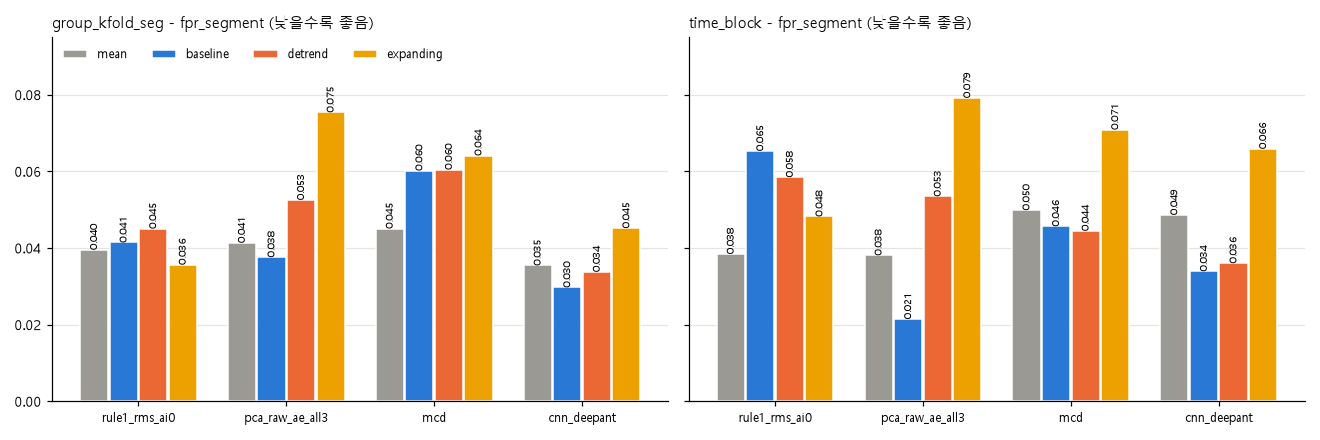

saved figures\13_preprocess_dc_check_CHS\variant_auc.png


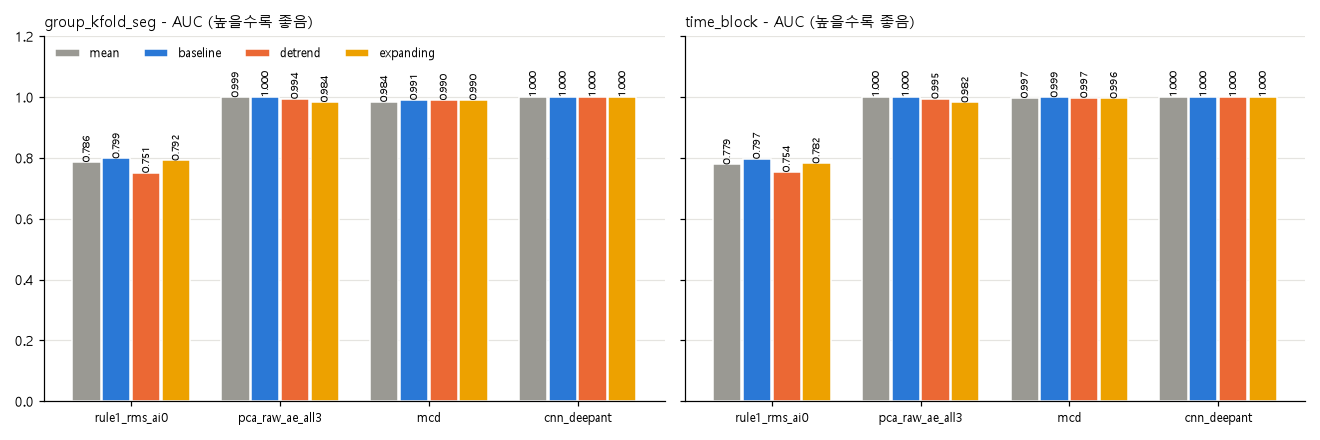

In [21]:
COL = {"mean": "#9a9993", "baseline": "#2a78d6", "detrend": "#eb6834", "expanding": "#eda100"}
MODELS = ["rule1_rms_ai0", "pca_raw_ae_all3", "mcd", "cnn_deepant"]
def bar_fig(metric, title, fname, fmt="{:.3f}"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, sp in zip(axes, ["group_kfold_seg", "time_block"]):
        d = variant_metrics[variant_metrics.split == sp]
        for j, v in enumerate(VARIANTS):
            vals = [float(d[(d.variant == v) & (d.model_id == m)][metric].iloc[0]) for m in MODELS]
            xs = np.arange(len(MODELS)) + (j - 1.5) * 0.2
            ax.bar(xs, vals, 0.19, color=COL[v], label=v, edgecolor="white")
            for x_, y_ in zip(xs, vals):
                ax.text(x_, y_, fmt.format(y_), ha="center", va="bottom", fontsize=6.5, rotation=90)
        ax.set_xticks(range(len(MODELS)), MODELS, fontsize=8)
        ax.set_title(f"{sp} - {title}", loc="left", fontsize=10)
        ax.grid(axis="x", visible=False)
    axes[0].margins(y=0.2)
    axes[0].legend(frameon=False, fontsize=8, ncol=4, loc="upper left")
    paths.save_fig(FIG, fname)
    display(Image(FIG / fname))
bar_fig("fpr_segment", "fpr_segment (낮을수록 좋음)", "variant_fpr_segment.png")
bar_fig("auc", "AUC (높을수록 좋음)", "variant_auc.png")

**결과**(group_kfold_seg 5 / time_block 4 fold 평균, 시드 0): 검증으로 `mean`·`rule1`의 gkf AUC 0.7864 · fpr_segment 0.0395가 21 결과와 일치한다. 변형별 비교는 D절 표에 정리한다. 미탐 세그먼트(`fn_by_variant.csv`): `rule1`은 4변형 모두 3·19·20, `cnn_deepant`는 4변형 모두 미탐 0, `mcd`·`pca_raw_ae_all3`는 `mean`·`baseline`에서 0이고 `detrend`에서 `pca_raw_ae_all3`가 19·20, `expanding`에서 `pca_raw_ae_all3`가 3·19·20, `mcd`(gkf)가 19를 놓친다.

**시사점**: `baseline`은 `mean`과 탐지 수가 같고(미탐 동일) 복원 계열(`pca_raw_ae_all3`)·`cnn_deepant`의 fpr_segment를 낮추지만(단 `pca_raw_ae_all3` gkf 0.0413 → 0.0376은 fold당 세그먼트 0.4개 수준의 노이즈), `mcd`(gkf)와 `rule1`(time_block)에서는 높아져 모든 모델에서 일관된 우위는 아니다. fold당 정상 test 세그먼트가 약 100개라 0.01 차이는 세그먼트 1개 수준이므로 개선 폭은 노이즈와 구분하기 어렵다. `detrend`는 8칸 중 5칸에서 오경보가 늘고(`mcd` tb·`cnn_deepant` 두 split은 오히려 낮음) `pca_raw_ae_all3`가 19·20을 잃는다. `expanding`은 `rule1` gkf를 제외한 모든 칸에서 오경보가 늘고 `pca_raw_ae_all3`(3·19·20)·`mcd` gkf(19)가 탐지를 잃는다.

### B-3 세그먼트 안 위치 효과 (기동 과도 → 오경보 조건)

`mean`과 `baseline`의 `pca_raw_ae_all3` group_kfold_seg test 점수에서 **정상** 윈도우를 윈도우 시작 시각(`t_start`)으로 묶는다(0초 / 0.5~1.5초 / 2~3초 / 3.5~4초). 세그먼트 시작 윈도우가 뒤쪽보다 높으면 DC·위상 처리가 기동 구간에서 AC를 왜곡한다는 뜻이다. 변형마다 임계가 달라 점수 절대값은 비교하지 않고 점수 ÷ 임계와 초과율을 본다.

saved figures\13_preprocess_dc_check_CHS\position_effect.png


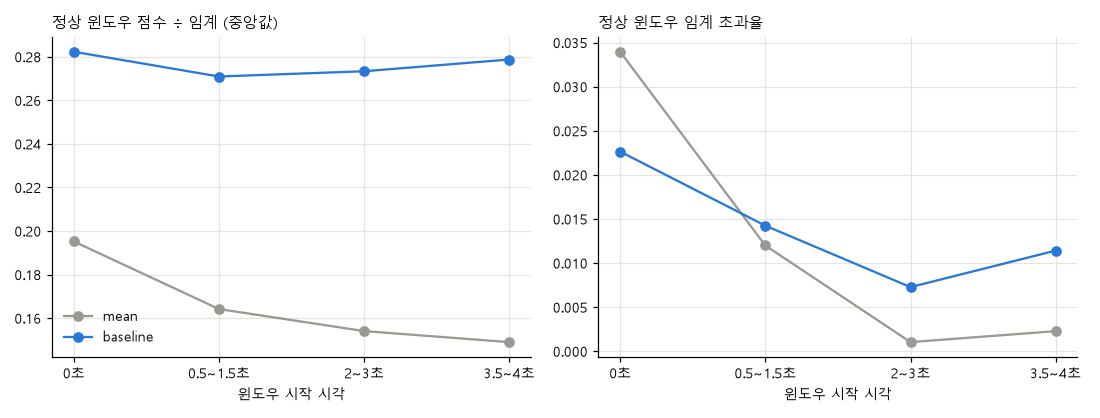

,variant,t_start_bin,n_windows,median_score,median_score_over_thr,exceed_rate
0,mean,0초,530,0.9280,0.1953,0.0340
1,mean,0.5~1.5초,1334,0.7874,0.1642,0.0120
2,mean,2~3초,962,0.7418,0.1541,0.0010
3,mean,3.5~4초,438,0.7239,0.1490,0.0023
4,baseline,0초,530,0.9048,0.2823,0.0226
5,baseline,0.5~1.5초,1334,0.8707,0.2709,0.0142
6,baseline,2~3초,962,0.8880,0.2734,0.0073
7,baseline,3.5~4초,438,0.8950,0.2787,0.0114


In [22]:
rows = []
bins = [("0초", 0.0, 0.0), ("0.5~1.5초", 0.5, 1.5), ("2~3초", 2.0, 3.0), ("3.5~4초", 3.5, 4.0)]
for v in ["mean", "baseline"]:
    s = STORE["pca_scores"][v]
    s = s[(s["split"] == "group_kfold_seg") & (s["label"] == 0) & (s["part"] == "test")]
    for nm, lo, hi in bins:
        d = s[(s["t_start"] >= lo - 1e-9) & (s["t_start"] <= hi + 1e-9)]
        rows.append({"variant": v, "t_start_bin": nm, "n_windows": len(d), "median_score": d["score"].median(),
                     "median_score_over_thr": (d["score"] / d["thr"]).median(), "exceed_rate": d["exceed"].mean()})
position = pd.DataFrame(rows)
position.to_csv(RES / "position_effect.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for v in ["mean", "baseline"]:
    d = position[position.variant == v]
    axes[0].plot(d["t_start_bin"], d["median_score_over_thr"], marker="o", color=COL[v], label=v)
    axes[1].plot(d["t_start_bin"], d["exceed_rate"], marker="o", color=COL[v], label=v)
axes[0].set_title("정상 윈도우 점수 ÷ 임계 (중앙값)", loc="left", fontsize=10)
axes[1].set_title("정상 윈도우 임계 초과율", loc="left", fontsize=10)
axes[0].legend(frameon=False); axes[0].set_xlabel("윈도우 시작 시각"); axes[1].set_xlabel("윈도우 시작 시각")
paths.save_fig(FIG, "position_effect.png")
display(Image(FIG / "position_effect.png"))
position.round(4)

**결과**(`pca_raw_ae_all3`, gkf test 정상 윈도우): `mean`은 시작 윈도우(0초, 530개)의 임계 초과율이 3.40%이고 0.5~1.5초 1.20%, 2~3초 0.10%, 3.5~4초 0.23%로 줄어들며, 점수 ÷ 임계 중앙값도 0.195 → 0.164 → 0.154 → 0.149로 내려간다. `baseline`은 초과율 2.26% / 1.42% / 0.73% / 1.14%, 점수 ÷ 임계 중앙값 0.282 / 0.271 / 0.273 / 0.279로 위치에 따른 변화가 거의 없다.

**시사점**: 세그먼트 평균 제거는 세그먼트 앞부분 윈도우의 점수를 약 31% 높인다(0초 0.195 vs 3.5~4초 0.149). `baseline`은 이 위치 의존성을 없애지만, 시작 윈도우 초과율은 여전히 가장 높다(2.26%). 따라서 `mean`의 시작 구간 초과율 3.40% 중 1.14%p는 세그먼트 평균 제거(위상 혼입)가 만든 몫이고, `baseline`에 남는 2.26%(뒤쪽 윈도우 대비 약 1.1%p 초과)는 DC 처리와 무관한 기동 과도로 보인다. 단 `baseline`은 뒤쪽 윈도우 초과율을 오히려 높이므로(2~3초 0.10 → 0.73%, 3.5~4초 0.23 → 1.14%) 위치 의존성 제거가 곧 오경보 감소는 아니며, 변형마다 임계가 달라 초과율의 변형 간 비교는 근사다. 경보 운영에서는 세그먼트 시작 윈도우를 별도로 다뤄야 한다(심사 4번).

## C. DC 보조 지표 (판정 보드 #5, B안)

`baseline` 변형에서 세그먼트별 전류 잔여 DC(= 기저선 제거 후 세그먼트 평균)를 단독 경보 지표로 쓸 수 있는지 본다. n ≥ 17(0.6 Hz 한 주기 이상) 세그먼트만 대상으로 정상 잔여 |DC|의 q99를 임계로 두고, 이상 세그먼트 중 초과 수·번호(19·20 포함 여부), 정상 세그먼트 중 초과 수(오경보), |DC| 단독 AUC를 본다. 길이 조건을 n ≥ 10으로 낮추면 짧은 세그먼트의 위상 혼입으로 오경보가 느는지도 같은 표에 둔다. 임계 q99는 정상 전체에서 추정한 값이라(분할 없음) 진단용 수치이고 일반화 성능이 아니다.

saved figures\13_preprocess_dc_check_CHS\dc_aux_indicator.png


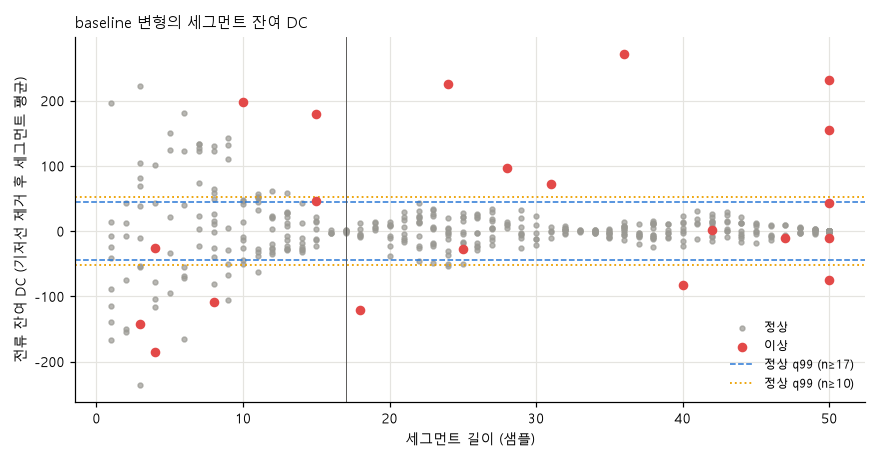

,0,1
min_len,17,10
n_normal_seg,469,530
n_outlier_seg,14,17
thr_abs_dc_q99,44.131,52.1109
n_outlier_exceed,9,11
outlier_exceed_segs,"3,4,6,7,13,15,16,17,18","3,4,6,7,13,15,16,17,18,19,20"
includes_19,False,True
includes_20,False,True
n_normal_exceed_fp,5,6
fp_seg_rate,0.0107,0.0113


In [23]:
pb = pre_by["baseline"]
seg_res = pb.groupby("seg_uid", sort=False).agg(src=("src", "first"), n=("AI2_Current", "size"), res_dc=("AI2_Current", "mean"))
seg_res["label"] = (seg_res["src"] == "outlier").astype(int)
seg_res["abs_dc"] = seg_res["res_dc"].abs()
rows = []
for min_len in [17, 10]:
    d = seg_res[seg_res.n >= min_len]
    nm, ol = d[d.label == 0], d[d.label == 1]
    thr = float(nm["abs_dc"].quantile(0.99))
    ex = ol[ol["abs_dc"] > thr]
    nums = sorted(int(u.split("_")[1]) for u in ex.index)
    rows.append({"min_len": min_len, "n_normal_seg": len(nm), "n_outlier_seg": len(ol), "thr_abs_dc_q99": thr,
                 "n_outlier_exceed": len(ex), "outlier_exceed_segs": ",".join(map(str, nums)),
                 "includes_19": 19 in nums, "includes_20": 20 in nums,
                 "n_normal_exceed_fp": int((nm["abs_dc"] > thr).sum()), "fp_seg_rate": float((nm["abs_dc"] > thr).mean()),
                 "auc_abs_dc": ev.auc(d["label"], d["abs_dc"]),
                 "outlier_abs_dc_min": float(ol["abs_dc"].min()) if len(ol) else np.nan, "normal_abs_dc_max": float(nm["abs_dc"].max())})
dc_aux = pd.DataFrame(rows)
dc_aux.to_csv(RES / "dc_aux_indicator.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 4.2))
nmv = seg_res[seg_res.label == 0]; olv = seg_res[seg_res.label == 1]
ax.scatter(nmv["n"], nmv["res_dc"], s=10, c="#9a9993", alpha=0.7, label="정상")
ax.scatter(olv["n"], olv["res_dc"], s=28, c="#e34948", zorder=3, label="이상")
t17 = float(dc_aux.loc[dc_aux.min_len == 17, "thr_abs_dc_q99"].iloc[0])
t10 = float(dc_aux.loc[dc_aux.min_len == 10, "thr_abs_dc_q99"].iloc[0])
for s_ in (1, -1):
    ax.axhline(s_ * t17, color="#2a78d6", ls="--", lw=1, label="정상 q99 (n≥17)" if s_ == 1 else None)
    ax.axhline(s_ * t10, color="#eda100", ls=":", lw=1.2, label="정상 q99 (n≥10)" if s_ == 1 else None)
ax.axvline(17, color="#52514e", lw=0.6)
ax.set_xlabel("세그먼트 길이 (샘플)"); ax.set_ylabel("전류 잔여 DC (기저선 제거 후 세그먼트 평균)")
ax.set_title("baseline 변형의 세그먼트 잔여 DC", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8)
paths.save_fig(FIG, "dc_aux_indicator.png")
display(Image(FIG / "dc_aux_indicator.png"))
dc_aux.round(4).T

**결과**: n ≥ 17(정상 469 / 이상 14)에서 정상 잔여 |DC| q99 = 44.13을 임계로 하면 이상 9개(3·4·6·7·13·15·16·17·18)가 초과하고 19·20은 길이가 17 미만이라 평가 대상이 아니며, 정상 초과 5개(1.07%), 단독 AUC 0.9229다. n ≥ 10(정상 530 / 이상 17)로 낮추면 임계 52.11, 이상 11개(위 9개 + 19·20) 초과, 정상 초과 6개(1.13%), AUC 0.9196이다. 이상 세그먼트 잔여 |DC| 최소는 1.33(DC 이상이 없는 이상도 있음), 정상 최대는 63.3(n ≥ 10)이다.

**시사점**: 잔여 DC는 단변량 규칙 가운데 19·20(n 10~16)까지 잡는 지표이고(다변량 모델 `pca_raw_ae_all3`·`mcd`·`cnn_deepant`는 `mean` 변형에서도 19·20을 탐지한다), 길이 조건을 10으로 낮춰도 정상 오경보 비율은 1.07% → 1.13%로 거의 늘지 않는다(임계가 44.1 → 52.1로 올라 위상 혼입을 흡수). 반면 임계가 올라가므로 DC 이탈이 작은 이상은 그대로 놓친다. **판정 보드 #5 권고**: 모델 입력 피처로는 쓰지 않고(02 진단의 형식 누수 채널 |DC|와 같은 신호라 날짜 = 라벨 교란을 배제할 수 없음), 현장 경보의 **보조 지표**(주 점수와 OR 결합, n ≥ 10 세그먼트에 한해 `baseline` 잔여 DC > 정상 q99)로만 채택한다. 이벤트 1건 · 임계가 정상 전체 추정값이라는 한계를 보고서에 함께 적는다.

## D. 결론

1. **DC 진단**: 정상 전류의 DC는 사실상 상수다(길이 50 세그먼트 평균 q50 0.57, |DC| q95 1.19, 세그먼트 내 `lin_r2` q50 0.023). 이상 세그먼트는 드리프트를 포함한다(`lin_r2` q50 0.136 · q95 0.696, `lf_frac` q95 0.528, 길이 24 이상 이상 13개 중 8개가 정상 |DC| 최대 52.9를 초과). 짧은 세그먼트의 평균은 DC가 아니라 위상값이다(Spearman |DC|-길이 −0.835, 길이 8 이하 |DC| q95 182 vs 50은 1.2, 평균 제거 후 RMS 잔존율 n=5 47% · n=10 84% · n=17 100%). 정상의 21.7%(130/599)가 n<17이다.
2. **하이패스 기각**: AC를 보존하는 fc에서는 DC 스텝이 지워지지 않는다. fc=0.1 causal은 상대 오차 0.253이지만 DC 스텝 첫 1초 오차 123(AC std 104 초과)·4~5초 37.8이 남고, fc=0.2는 zero-phase 0.420 / causal 0.489이며 causal 첫 1초 오차 98.0, fc ≥ 0.5는 0.6 Hz AC 자체를 왜곡(causal 1.08 이상)한다.
3. **변형별 대표 모델 결과**(fpr_segment, 낮을수록 좋음 / 이상 탐지 수; gkf는 5 fold 합계 ÷ 17, tb는 fold 평균 ÷ 17):

| 모델 | split | mean | baseline | detrend | expanding |
|---|---|---|---|---|---|
| rule1_rms_ai0 | gkf | 0.0395 / 14 | 0.0414 / 14 | 0.0450 / 14 | 0.0356 / 14 |
| rule1_rms_ai0 | tb | 0.0384 / 14 | 0.0653 / 14 | 0.0585 / 14 | 0.0482 / 14 |
| pca_raw_ae_all3 | gkf | 0.0413 / 17 | 0.0376 / 17 | 0.0525 / 15 | 0.0754 / 14 |
| pca_raw_ae_all3 | tb | 0.0381 / 17 | 0.0215 / 17 | 0.0535 / 15 | 0.0792 / 14 |
| mcd | gkf | 0.0451 / 17 | 0.0602 / 17 | 0.0605 / 17 | 0.0641 / 16 |
| mcd | tb | 0.0499 / 17 | 0.0457 / 17 | 0.0445 / 17 | 0.0709 / 17 |
| cnn_deepant | gkf | 0.0354 / 17 | 0.0297 / 17 | 0.0338 / 17 | 0.0452 / 17 |
| cnn_deepant | tb | 0.0486 / 17 | 0.0339 / 17 | 0.0360 / 17 | 0.0659 / 17 |

   - `baseline` vs `mean`: 탐지 수는 모든 모델에서 같고(미탐 `rule1` 3·19·20, 나머지 0), 복원·예측 계열은 fpr_segment가 낮아졌다(`pca_raw_ae_all3` gkf 0.0413 → 0.0376은 fold당 세그먼트 0.4개 수준의 노이즈, tb 0.0381 → 0.0215, `cnn_deepant` gkf 0.0354 → 0.0297, tb 0.0486 → 0.0339). `mcd` gkf(0.0451 → 0.0602)와 `rule1` tb(0.0384 → 0.0653)는 높아졌다. 모델 전반에 걸친 일관된 개선은 아니며 fold당 정상 test 세그먼트 약 100개 기준 0.01은 세그먼트 1개 수준이다. **주의(B-1 누수 점검)**: `baseline`·`expanding`은 이상 파일의 세그먼트 DC를 제거하지 않으므로 실제 이상 AUC·탐지 수의 이득은 파형이 아니라 DC(계측 체인 변경과 실제 이상의 구분 불가, 판정 보드 #5)에서 올 수 있다. 파형 탐지의 정직한 비교는 `mean` vs `detrend`이고 `baseline`의 실제 이상 수치는 상한이다.
   - `detrend`: 17~20 탐지가 **모델에 따라 유지되지 않는다**. `mcd`·`cnn_deepant`는 17개 모두 탐지하지만 `pca_raw_ae_all3`는 19·20을 놓치고(15/17), 오경보는 8칸 중 5칸에서 `mean`보다 높다(`pca_raw_ae_all3` 0.0525 / 0.0535, `mcd` gkf 0.0605; 반면 `mcd` tb 0.0445·`cnn_deepant` 0.0338 / 0.0360은 낮다). `pca_raw_ae_all3`의 19·20 미탐은 두 세그먼트의 이상이 DC·저주파에 있다는 해석과 맞지만 근거는 모델 1종이다.
   - `expanding`: `rule1` gkf(0.0356)를 빼면 가장 나쁘다. fpr_segment가 `pca_raw_ae_all3` 0.0754 / 0.0792, `mcd` 0.0641 / 0.0709, `cnn_deepant` 0.0452 / 0.0659로 `mean`보다 높고, `pca_raw_ae_all3`는 3·19·20(14/17), `mcd`(gkf)는 19를 놓친다. 누적 평균이 세그먼트 앞부분에서 `mean`과 같은 위상 편향을 갖고 뒤로 갈수록 값이 바뀌는 구조가 원인으로 추정되나, 위치 효과(B-3)는 `mean`·`baseline`만 측정했다.
4. **위치 효과**: `mean`은 세그먼트 시작 윈도우의 정상 초과율 3.40%(0.5~1.5초 1.20%, 2~3초 0.10%, 3.5~4초 0.23%), 점수 ÷ 임계 중앙값 0.195 → 0.149(−24%)로 시작이 높다. `baseline`은 중앙값이 0.282 / 0.271 / 0.273 / 0.279로 평탄하고 시작 초과율 2.26%로 낮아지지만 여전히 최고다(잔여 기동 과도). 다만 뒤쪽 윈도우 초과율은 `mean`보다 높아져(2~3초 0.10 → 0.73%, 3.5~4초 0.23 → 1.14%) 위치 의존성 제거가 오경보 총량 감소를 뜻하지는 않으며, 변형 간 임계가 달라 초과율 비교는 근사다.
5. **DC 보조 지표**: `baseline` 잔여 |DC| > 정상 q99는 n ≥ 17에서 이상 14개 중 9개(19·20 제외 — 길이 미달), 정상 오경보 5/469(1.07%), AUC 0.9229이고, n ≥ 10으로 낮추면 이상 17개 중 11개(19·20 포함), 정상 오경보 6/530(1.13%), AUC 0.9196이다. **판정 보드 #5 권고**: 모델 입력으로 쓰지 않고(형식 누수 채널과 같은 신호), 현장 경보의 보조 지표(n ≥ 10 세그먼트, 주 점수와 OR 결합)로만 채택한다. **주의**: 이 DC 신호는 02 §2의 파일 형식 누수(|DC| 단독 AUC AI0 0.9443 / AI1 0.9198 / AI2 0.8911)와 같은 양이라 실제 이상과 계측 체인 변경을 구분할 수 없다. 따라서 `baseline`·`expanding`의 실제 이상 수치는 DC가 도운 상한이고, 파형만의 비교는 `mean` vs `detrend`다.
6. **한계**: `baseline`은 분할마다 다시 적합하지 않고 정상 전체로 1회 적합했다(B-0에서 fold별 전류 값 0.502~0.596으로 변동은 확인). `cnn_deepant`는 시드 1개(30 epoch)다. 1초 윈도우만 비교했다. 이상 이벤트는 1건이고 정상 q99 임계·DC 보조 지표 임계는 정상 전체 추정값이라 일반화 성능이 아니다. `B.run`의 합성 이상 열(`variant_cv.csv`의 `inj_*`)은 주입 후 평균을 다시 빼는 규약 때문에 변형 간 비교에 쓰지 않았다. 진폭 18열 재계산 값은 float32 세그먼트 배열 때문에 parquet과 최대 절대 2.4e-5(`AI2_Current_p2p`), 최대 상대 4.7e-5 차이가 난다(`mean` 변형 재현 허용치 1e-6은 넘지만 값 크기 약 150인 전류 열의 float32 반올림 수준이다).
7. **다음 단계**: (a) `src/features.py`에 윈도우 상관 피처를 추가하는 별도 PR, (b) 이 노트북은 전처리 ablation이라 31 비교표(`results/*/metrics.csv` 수집)에는 반영하지 않는다(`metrics.csv`를 만들지 않음), (c) 입력 계약 v1에 `baseline`(정상 학습 구간 긴 세그먼트 기저선, causal) 추가를 제안한다. `mean`은 오프라인 benchmark_v1로 유지하고, 현장 적용 경로(4번)에서는 `baseline` + 시작 윈도우 별도 처리를 검토한다.

In [24]:
print(f"총 실행 시간 {(time.time() - t_nb) / 60:.1f}분 (노트북 시작 이후)")
print(sorted(p.name for p in RES.iterdir()))
print(sorted(p.name for p in FIG.iterdir()))

총 실행 시간 1.5분 (노트북 시작 이후)
['baseline_by_fold.csv', 'dc_aux_indicator.csv', 'dc_constancy.csv', 'dc_outlier_vs_normal_len24.csv', 'dc_vs_length.csv', 'fn_by_variant.csv', 'highpass_rejection.csv', 'leak_check_by_variant.csv', 'misc_quality.csv', 'position_effect.csv', 'seg_dc.csv', 'variant_cv.csv', 'variant_metrics.csv']
['dc_aux_indicator.png', 'dc_vs_length.png', 'highpass_example.png', 'position_effect.png', 'variant_auc.png', 'variant_fpr_segment.png']
